# 00 · Baseline MLP on the pendulum

**Purpose in this framework.** This notebook is the *control group* for every other
notebook in `evaluation_framework/`. It trains a plain, physics-**unaware**
multilayer perceptron (MLP) to regress the vector field of the nonlinear pendulum
directly, with no structural prior at all. This exactly reproduces the "Baseline NN"
of **Greydanus, Dzamba & Yosinski (2019), "Hamiltonian Neural Networks", Fig. 1**
(`papers/01_Fundamentos_y_Arquitecturas_Base/Greydanus et al 2019 - Hamiltonian
Neural Networks.pdf`): a network with the *same* number of parameters and the *same*
training data as the HNN in notebook `01`, but which predicts `(q_dot, p_dot)`
directly from `(q, p)` instead of deriving them from a learned scalar energy.

**Why it matters.** Every subsequent notebook (HNN, LNN, Symplectic ODE-Net,
SympNets) will be compared against *this* model using the same matched-integrator
protocol as **Kemunto, Gaba & Tewe (2026)**
(`papers/07_Evaluacion_y_Comparativas/A matched-integrator evaluation...pdf`,
summarised in section 7.1 of `Estado del Arte - Hamiltonian Neural Networks.pdf`):
same data, same optimizer settings, same RK4 integrator at inference time. The only
thing that changes across notebooks is the *architecture's inductive bias*. If you
are new to this literature: the headline empirical result of the whole field is that
this baseline's energy drifts (spirals in/out) over long rollouts, while
Hamiltonian-structured models keep energy (almost) constant by construction.

**For ML-literate readers with no physics background:** think of `(q, p)` as a
2-D state vector (angle, angular momentum) and of "energy conservation" simply as
"the learned dynamical system's trajectory should stay on the same level curve of a
scalar function H(q,p), rather than spiralling into an attractor or diverging" --
which is exactly the kind of instability an unconstrained regression model has no
reason to avoid.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    # Running as a plain script (e.g. `python 00_baseline_mlp_pendulum.py` for
    # development/testing) -> force a headless backend. Inside a Jupyter kernel we
    # keep matplotlib's own default so figures render inline in the notebook.
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

FRAMEWORK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(FRAMEWORK_ROOT))
from common import systems, metrics, models  # noqa: E402

RESULTS_DIR = FRAMEWORK_ROOT / "results"
FIGURES_DIR = FRAMEWORK_ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

## Step 1 — Generate the training data

Paper step: Greydanus et al. (2019), Sec. 3, "we generate training data ... by
sampling from the Hamiltonian... and adding the derivative as the target". We reuse
the exact same `sample_pendulum_dataset` for every notebook (see
`common/systems.py`) so that all models see identical data.

In [2]:
train_state, train_deriv = systems.sample_pendulum_dataset(n_points=2000, seed=SEED)
test_state, test_deriv = systems.sample_pendulum_dataset(n_points=400, seed=SEED + 1)

train_state_t = torch.tensor(train_state)
train_deriv_t = torch.tensor(train_deriv)

print(f"train set: {train_state.shape}, test set: {test_state.shape}")

train set: (2000, 2), test set: (400, 2)


## Step 2 — Define the baseline model

A plain MLP: `(q, p) -> (q_dot, p_dot)`, 2 hidden layers of 200 units (same capacity
budget as the HNN's scalar network in notebook `01`, which is the "parameter-matched"
condition emphasised by Kemunto et al., 2026).

In [3]:
baseline = models.MLP(in_dim=2, hidden_dim=200, out_dim=2, n_hidden_layers=2)
print("baseline parameter count:", models.count_parameters(baseline))

baseline parameter count: 41202


## Step 3 — Train by regressing the instantaneous derivative

This is a standard supervised-regression training loop: minimise
`MSE(model(q, p), (q_dot, p_dot))`. There is *no* rollout / integration happening
during training -- exactly as in Greydanus et al. (2019). Rollout only happens at
evaluation time (Step 4), which is where the baseline's lack of structure becomes
visible.

In [4]:
optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)
n_epochs = 2000
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = baseline(train_state_t)
    loss = ((pred - train_deriv_t) ** 2).mean()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f"epoch {epoch:4d}  train MSE = {loss.item():.3e}")

print(f"final train MSE = {losses[-1]:.3e}")

epoch    0  train MSE = 8.555e-01


epoch  400  train MSE = 1.283e-03


epoch  800  train MSE = 2.050e-04


epoch 1200  train MSE = 1.206e-04


epoch 1600  train MSE = 7.530e-05


final train MSE = 5.782e-05


## Step 4 — Roll out a trajectory and check energy conservation

We integrate the *learned* vector field forward with the same RK4 integrator used
for the ground truth (`common.systems.integrate`), starting from an out-of-training
initial condition, and compare against the true trajectory. This is the diagnostic
that appears in Fig. 1 of Greydanus et al. (2019): a spiral in phase space and a
drifting energy curve.

In [5]:
def baseline_vector_field(state, **kwargs):
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        return baseline(s).squeeze(0).numpy()


q0, p0 = 1.6, 0.0  # a moderately nonlinear initial condition, away from small-angle regime
state0 = np.array([q0, p0])
T_SPAN, DT = 20.0, 0.05

true_traj = systems.integrate(systems.pendulum_dynamics, state0, T_SPAN, DT)
pred_traj = systems.integrate(baseline_vector_field, state0, T_SPAN, DT)

H_true, _, _ = metrics.energy_drift(true_traj, systems.pendulum_hamiltonian)
H_pred, abs_drift, rel_drift = metrics.energy_drift(pred_traj, systems.pendulum_hamiltonian)
traj_mse = metrics.trajectory_mse(pred_traj, true_traj)

print(f"trajectory MSE over rollout: {traj_mse:.4e}")
print(f"max |energy drift|:          {abs_drift.max():.4e}")
print(f"max relative energy drift:   {rel_drift.max():.4e}")

trajectory MSE over rollout: 8.1821e-03
max |energy drift|:          1.2982e-01
max relative energy drift:   1.2614e-01


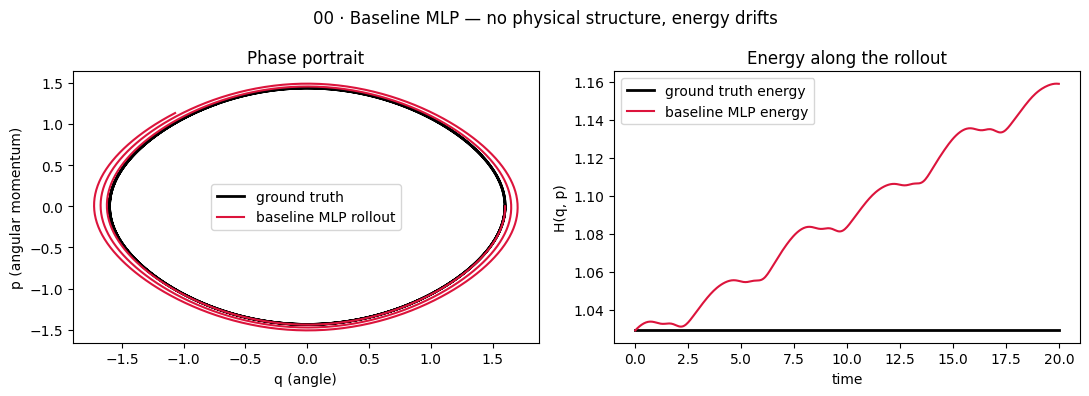

In [6]:
t = np.arange(len(true_traj)) * DT
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(true_traj[:, 0], true_traj[:, 1], label="ground truth", color="black", lw=2)
axes[0].plot(pred_traj[:, 0], pred_traj[:, 1], label="baseline MLP rollout", color="crimson", lw=1.5)
axes[0].set_xlabel("q (angle)")
axes[0].set_ylabel("p (angular momentum)")
axes[0].set_title("Phase portrait")
axes[0].legend()

axes[1].plot(t, H_true, label="ground truth energy", color="black", lw=2)
axes[1].plot(t, H_pred, label="baseline MLP energy", color="crimson", lw=1.5)
axes[1].set_xlabel("time")
axes[1].set_ylabel("H(q, p)")
axes[1].set_title("Energy along the rollout")
axes[1].legend()

fig.suptitle("00 · Baseline MLP — no physical structure, energy drifts")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_baseline_mlp_pendulum.png", dpi=130)
plt.show()

## Step 5 — Save the trained model and metrics

Saved so that `05_comparativa_unificada.py` can load every model's results without
re-training, and so the raw numbers behind the state-of-the-art document's claims
are reproducible from this framework.

In [7]:
torch.save(baseline.state_dict(), RESULTS_DIR / "baseline_mlp_pendulum.pt")

result = {
    "model": "baseline_mlp",
    "system": "pendulum",
    "n_params": models.count_parameters(baseline),
    "final_train_mse": losses[-1],
    "rollout_trajectory_mse": traj_mse,
    "max_abs_energy_drift": float(abs_drift.max()),
    "max_rel_energy_drift": float(rel_drift.max()),
}
with open(RESULTS_DIR / "baseline_mlp_pendulum_metrics.json", "w") as f:
    json.dump(result, f, indent=2)

np.save(RESULTS_DIR / "baseline_mlp_pendulum_rollout.npy", pred_traj)
np.save(RESULTS_DIR / "pendulum_ground_truth_rollout.npy", true_traj)

print(json.dumps(result, indent=2))

{
  "model": "baseline_mlp",
  "system": "pendulum",
  "n_params": 41202,
  "final_train_mse": 5.7823501265374944e-05,
  "rollout_trajectory_mse": 0.008182133118194317,
  "max_abs_energy_drift": 0.12982343574479027,
  "max_rel_energy_drift": 0.12614020087485392
}


## Take-away for the comparison notebook

Keep this energy-drift number in mind: it is the number every physics-informed
architecture in this framework (`01`-`04`) is trying to drive down to (near) zero,
*without* being given the Hamiltonian analytically -- only by virtue of their
architectural inductive bias.